# EEG-CLIP with 4-Class Contrastive Learning - Direct Embedding

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import torchmetrics
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from typing import Any, Dict, List, Tuple, Union
import matplotlib.pyplot as plt

# For pre-trained text encoder
from sentence_transformers import SentenceTransformer

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MKL-DNN disabled for CPU compatibility")

PyTorch version: 2.6.0+cu124
CUDA available: True
MKL-DNN disabled for CPU compatibility


In [3]:
# ATCNet Model Implementation - Modified for Direct Embedding Output
# Attention-based Temporal Convolutional Network for EEG classification

class ATCNetDirectEmbedding(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 embedding_dim: int = 384,
                 num_windows: int = 3,
                 num_electrodes: int = 22,
                 conv_pool_size: int = 7,
                 F1: int = 16,
                 D: int = 2,
                 tcn_kernel_size: int = 4,
                 tcn_depth: int = 2,
                 chunk_size: int = 1125):
        super(ATCNetDirectEmbedding, self).__init__()
        self.in_channels = in_channels
        self.embedding_dim = embedding_dim
        self.num_windows = num_windows
        self.num_electrodes = num_electrodes
        self.pool_size = conv_pool_size
        self.F1 = F1
        self.D = D
        self.tcn_kernel_size = tcn_kernel_size
        self.tcn_depth = tcn_depth
        self.chunk_size = chunk_size
        F2 = F1*D

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, F1, (1, int(chunk_size/2+1)),
                      stride=1, padding='same', bias=False),
            nn.BatchNorm2d(F1, False),
            nn.Conv2d(F1, F2, (num_electrodes, 1), padding=0, groups=F1),
            nn.BatchNorm2d(F2, False),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout2d(0.1),
            nn.Conv2d(F2, F2, (1, 16), bias=False, padding='same'),
            nn.BatchNorm2d(F2, False),
            nn.ELU(),
            nn.AvgPool2d((1, self.pool_size)),
            nn.Dropout2d(0.1)
        )
        self.__build_model()

    def __build_model(self):
        with torch.no_grad():
            x = torch.zeros(2, self.in_channels,
                            self.num_electrodes, self.chunk_size)
            x = self.conv_block(x)
            x = x[:, :, -1, :]
            x = x.permute(0, 2, 1)
            self.__chan_dim, self.__embed_dim = x.shape[1:]
            self.win_len = self.__chan_dim - self.num_windows + 1

            for i in range(self.num_windows):
                st = i
                end = x.shape[1] - self.num_windows+i+1
                x2 = x[:, st:end, :]

                self.__add_msa(i)
                x2_ = self.get_submodule("msa"+str(i))(x2, x2, x2)[0]
                self.__add_msa_drop(i)
                x2_ = self.get_submodule("msa_drop"+str(i))(x2)
                x2 = torch.add(x2, x2_)

                for j in range(self.tcn_depth):
                    self.__add_tcn((i+1)*j, x2.shape[1])
                    out = self.get_submodule("tcn"+str((i+1)*j))(x2)
                    if x2.shape[1] != out.shape[1]:
                        self.__add_recov(i)
                        x2 = self.get_submodule("re"+str(i))(x2)
                    x2 = torch.add(x2, out)
                    x2 = nn.ELU()(x2)
                x2 = x2[:, -1, :]
                self.__dense_dim = x2.shape[-1]
                # Instead of outputting num_classes, output intermediate features
                self.__add_feature_projection(i)
                x2 = self.get_submodule("feature_proj"+str(i))(x2)
            
            # Calculate concatenated feature dimension
            self.__concat_feature_dim = x2.shape[-1] * self.num_windows
            
            # Add final projection to embedding dimension
            self.__add_final_projection()

    def __add_msa(self, index: int):
        self.add_module('msa'+str(index), nn.MultiheadAttention(
            embed_dim=self.__embed_dim,
            num_heads=2,
            batch_first=True))

    def __add_msa_drop(self, index):
        self.add_module('msa_drop'+str(index), nn.Dropout(0.3))

    def __add_tcn(self, index: int, num_electrodes: int):
        self.add_module('tcn'+str(index),
                        nn.Sequential(
            nn.Conv1d(num_electrodes, 32,
                      self.tcn_kernel_size, padding='same'),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Conv1d(32, 32, self.tcn_kernel_size, padding='same'),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.3))
        )

    def __add_recov(self, index: int):
        self.add_module('re'+str(index),
                        nn.Conv1d(self.win_len, 32, 4, padding='same'))

    def __add_feature_projection(self, index: int):
        """Project to intermediate feature dimension (not class labels)"""
        # Output larger feature dimension instead of num_classes
        intermediate_dim = 256
        self.add_module('feature_proj'+str(index),
                        nn.Sequential(
                            nn.Linear(self.__dense_dim, intermediate_dim),
                            nn.ReLU(),
                            nn.Dropout(0.1)
                        ))
    
    def __add_final_projection(self):
        """Final projection from concatenated features to embedding dimension"""
        self.final_projection = nn.Sequential(
            nn.Linear(self.__concat_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 768),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(768, self.embedding_dim)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x[:, :, -1, :]
        x = x.permute(0, 2, 1)

        window_features = []
        for i in range(self.num_windows):
            st = i
            end = x.shape[1] - self.num_windows+i+1
            x2 = x[:, st:end, :]
            x2_ = self.get_submodule("msa"+str(i))(x2, x2, x2)[0]
            x2_ = self.get_submodule("msa_drop"+str(i))(x2)
            x2 = torch.add(x2, x2_)

            for j in range(self.tcn_depth):
                out = self.get_submodule("tcn"+str((i+1)*j))(x2)
                if x2.shape[1] != out.shape[1]:
                    x2 = self.get_submodule("re"+str(i))(x2)
                x2 = torch.add(x2, out)
                x2 = nn.ELU()(x2)
            x2 = x2[:, -1, :]
            x2 = self.get_submodule("feature_proj"+str(i))(x2)
            window_features.append(x2)

        # Concatenate features from all windows
        concat_features = torch.cat(window_features, dim=1)
        
        # Project to final embedding dimension
        embeddings = self.final_projection(concat_features)
        
        # Normalize embeddings
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
        return embeddings

print("ATCNetDirectEmbedding model class defined successfully!")

ATCNetDirectEmbedding model class defined successfully!


In [4]:
# ============================================================================
# 4-CLASS TEMPLATES - EDIT THESE FOR YOUR ACTION DESCRIPTIONS
# ============================================================================

class ClassTemplates:
    """
    Defines the 4 fixed class descriptions.
    These are the ONLY text captions used during training.
    """
    
    def __init__(self, template_style='action_focused'):
        """
        Args:
            template_style: Choose template style
                - 'simple': Just action names
                - 'action_focused': Emphasize the action
                - 'motor_imagery': Motor imagery context
                - 'neural': Neural/brain activity context
        """
        self.template_style = template_style
        
        # ====================================================================
        # EDIT THESE TEMPLATES FOR DIFFERENT CAPTION STYLES
        # ====================================================================
        
        # Simple: Just the action name
        self.simple_templates = [
            "left hand",
            "right hand",
            "foot",
            "rest"
        ]
        
        # Action-focused: Emphasize the movement
        self.action_focused_templates = [
            "left hand movement",
            "right hand movement",
            "foot movement",
            "resting state"
        ]
        
        # Motor imagery: Explicit motor imagery context
        self.motor_imagery_templates = [
            "imagining left hand movement",
            "imagining right hand movement",
            "imagining foot movement",
            "no motor imagery"
        ]
        
        # Neural: Brain activity context
        self.neural_templates = [
            "brain activity during left hand motor imagery",
            "brain activity during right hand motor imagery",
            "brain activity during foot motor imagery",
            "brain activity during rest"
        ]
        
        # Descriptive: More detailed descriptions
        self.descriptive_templates = [
            "person performing left hand grasping motion",
            "person performing right hand grasping motion",
            "person performing foot dorsiflexion movement",
            "person in relaxed resting state"
        ]
        
        # Select templates based on style
        self.templates = self._get_templates()
        
        print(f"\n{'='*80}")
        print(f"CLASS TEMPLATES - Style: '{template_style}'")
        print(f"{'='*80}")
        for i, template in enumerate(self.templates):
            print(f"  Class {i}: '{template}'")
        print(f"{'='*80}\n")
    
    def _get_templates(self):
        if self.template_style == 'simple':
            return self.simple_templates
        elif self.template_style == 'action_focused':
            return self.action_focused_templates
        elif self.template_style == 'motor_imagery':
            return self.motor_imagery_templates
        elif self.template_style == 'neural':
            return self.neural_templates
        elif self.template_style == 'descriptive':
            return self.descriptive_templates
        else:
            return self.action_focused_templates
    
    def get_class_caption(self, class_idx):
        """Get caption for a specific class index (0-3)"""
        return self.templates[class_idx]
    
    def get_all_captions(self):
        """Get all 4 class captions"""
        return self.templates


# Test different styles
print("\nTesting different template styles:\n")
for style in ['simple', 'action_focused', 'motor_imagery', 'neural', 'descriptive']:
    templates = ClassTemplates(template_style=style)

print("ClassTemplates class defined successfully!")


Testing different template styles:


CLASS TEMPLATES - Style: 'simple'
  Class 0: 'left hand'
  Class 1: 'right hand'
  Class 2: 'foot'
  Class 3: 'rest'


CLASS TEMPLATES - Style: 'action_focused'
  Class 0: 'left hand movement'
  Class 1: 'right hand movement'
  Class 2: 'foot movement'
  Class 3: 'resting state'


CLASS TEMPLATES - Style: 'motor_imagery'
  Class 0: 'imagining left hand movement'
  Class 1: 'imagining right hand movement'
  Class 2: 'imagining foot movement'
  Class 3: 'no motor imagery'


CLASS TEMPLATES - Style: 'neural'
  Class 0: 'brain activity during left hand motor imagery'
  Class 1: 'brain activity during right hand motor imagery'
  Class 2: 'brain activity during foot motor imagery'
  Class 3: 'brain activity during rest'


CLASS TEMPLATES - Style: 'descriptive'
  Class 0: 'person performing left hand grasping motion'
  Class 1: 'person performing right hand grasping motion'
  Class 2: 'person performing foot dorsiflexion movement'
  Class 3: 'person in re

In [5]:
# Multi-Subject ECoG/EEG Dataset - Simplified (no caption generation needed)

class MultiSubjectECoGDataset(Dataset):
    def __init__(self, 
                 file_list, 
                 freq_band=(1, 100), 
                 remove_bad=True, 
                 scale=True, 
                 transform=None, 
                 time_range=None):
        """
        PyTorch Dataset for loading multi-subject ECoG/EEG data.
        Returns (eeg_data, class_label) pairs.
        No text captions needed in dataset (handled by model).
        """
        self.transform = transform
        self.data = []
        self.labels = []
        self.scale = scale
        self.remove_bad = remove_bad
        self.freq_band = freq_band
        self.time_range = time_range

        for file in file_list:
            print(f'Loading and processing {file}')
            self._load_subject_data(file)

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"Loaded {len(self.data)} trials from {len(file_list)} subjects.")
        print(f"Data shape: {self.data.shape}")
        
        # Print class distribution
        unique, counts = np.unique(self.labels, return_counts=True)
        print(f"\nClass distribution:")
        class_names = ["left hand", "right hand", "foot", "rest"]
        for cls, count in zip(unique, counts):
            print(f"  Class {cls} ({class_names[cls]}): {count} samples")

    def _load_subject_data(self, file_path):
        # Load raw data
        raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)
        if self.remove_bad:
            raw.pick_types(ecog=True, eeg=True, exclude='bads')
        
        # Apply bandpass filter
        if self.freq_band:
            raw.filter(self.freq_band[0], self.freq_band[1], fir_design='firwin', verbose=False)

        # Get events and labels
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        print(f"  Found {len(events)} events")

        # Epoching
        if self.time_range:
            tmin, tmax = self.time_range
        else:
            tmin, tmax = 0, 4

        epochs = mne.Epochs(
            raw, events, event_id=event_id,
            tmin=tmin, tmax=tmax,
            baseline=None, preload=True, verbose=False
        )

        X = epochs.get_data()
        y = epochs.events[:, -1]

        # Scaling
        if self.scale:
            for ch in range(X.shape[1]):
                scaler = StandardScaler()
                X[:, ch, :] = scaler.fit_transform(X[:, ch, :])
        
        # Save data and labels
        for trial, label in zip(X, y):
            self.data.append(trial)
            # Convert to 0-indexed (0=left, 1=right, 2=foot, 3=rest)
            self.labels.append(int(label) - 1)
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sample = self.data[index]
        label = self.labels[index]

        # Convert to tensor
        sample = torch.from_numpy(sample).float().unsqueeze(0)
        label = torch.tensor(label).long()

        if self.transform:
            sample = self.transform(sample)

        return sample, label

print("MultiSubjectECoGDataset class defined successfully!")

MultiSubjectECoGDataset class defined successfully!


In [6]:
# Frozen Text Encoder (same as before)

class FrozenTextEncoder(nn.Module):
    """
    Completely FROZEN pre-trained text encoder.
    Outputs native 384-dimensional embeddings.
    """
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        super(FrozenTextEncoder, self).__init__()
        
        print(f"\nLoading FROZEN text encoder: {model_name}")
        self.encoder = SentenceTransformer(model_name)
        
        # FREEZE all parameters
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        self.encoder.eval()
        
        if 'mpnet' in model_name:
            self.output_dim = 768
        else:
            self.output_dim = 384
        
        print(f"✓ Text encoder FROZEN")
        print(f"✓ Output dimension: {self.output_dim}")
        
    def forward(self, texts):
        with torch.no_grad():
            embeddings = self.encoder.encode(
                texts,
                convert_to_tensor=True,
                show_progress_bar=False,
                normalize_embeddings=True
            )
        return embeddings
    
    def train(self, mode=True):
        return self

print("FrozenTextEncoder defined successfully!")

FrozenTextEncoder defined successfully!


In [7]:
# ============================================================================
# EEG-CLIP Model with 4-Class Comparison - Direct Embedding
# ============================================================================

class EEG_CLIP_4Class(nn.Module):
    """
    EEG-CLIP that compares each EEG against 4 fixed class descriptions.
    
    Key Innovation:
    - Pre-computes text embeddings for 4 classes (done once)
    - Each forward pass compares EEG vs these 4 fixed embeddings
    - More efficient and interpretable than batch-based CLIP
    - ATCNet outputs embeddings DIRECTLY (no 4-class bottleneck)
    """
    def __init__(self, 
                 num_classes=4,
                 num_electrodes=50,
                 chunk_size=1001,
                 embedding_dim=384,
                 temperature=0.07,
                 text_model='all-MiniLM-L6-v2',
                 class_templates=None):
        super(EEG_CLIP_4Class, self).__init__()
        
        assert num_classes == 4, "This model is designed for 4 classes"
        
        # EEG encoder - outputs embeddings directly
        self.eeg_encoder = ATCNetDirectEmbedding(
            in_channels=1,
            embedding_dim=embedding_dim,
            num_electrodes=num_electrodes,
            chunk_size=chunk_size
        )
        
        # Frozen text encoder
        self.text_encoder = FrozenTextEncoder(model_name=text_model)
        
        # Temperature
        self.temperature = nn.Parameter(torch.tensor(temperature))
        
        # Store class templates
        if class_templates is None:
            class_templates = ClassTemplates(template_style='action_focused')
        self.class_templates = class_templates
        
        # Pre-compute text embeddings for 4 classes (FROZEN, computed once)
        self._precompute_class_embeddings()
        
        print("\n" + "="*80)
        print("EEG-CLIP 4-Class Model - Direct Embedding")
        print("="*80)
        print(f"Architecture:")
        print(f"  EEG Encoder: ATCNet (Direct) → {embedding_dim} dim (TRAINABLE)")
        print(f"  Text Encoder: {text_model} → {embedding_dim} dim (FROZEN)")
        print(f"  Class embeddings: Pre-computed (4 fixed vectors)")
        print(f"  Temperature: {temperature} (learnable)")
        print(f"\nKey Difference:")
        print(f"  ATCNet outputs embeddings DIRECTLY")
        print(f"  No intermediate 4-class bottleneck")
        print(f"  Better feature learning capacity")
        print(f"\nTraining:")
        print(f"  Each EEG compared against 4 class embeddings")
        print(f"  Random baseline: 25% (1/4 classes)")
        print("="*80)
        
    def _precompute_class_embeddings(self):
        """
        Pre-compute text embeddings for all 4 classes.
        These are FIXED and never change during training.
        """
        print("\nPre-computing class embeddings...")
        class_captions = self.class_templates.get_all_captions()
        
        with torch.no_grad():
            class_embeddings = self.text_encoder(class_captions)  # (4, 384)
        
        # Register as buffer (not a parameter, moves with model to GPU/CPU)
        self.register_buffer('class_embeddings', class_embeddings)
        
        print(f"✓ Class embeddings computed: {self.class_embeddings.shape}")
        print(f"  These embeddings are FIXED (never updated during training)")
        
    def forward(self, eeg_data, labels=None):
        """
        Forward pass.
        
        Args:
            eeg_data: (batch_size, 1, num_electrodes, time_points)
            labels: (batch_size,) - class labels (0-3), optional
            
        Returns:
            logits: (batch_size, 4) - similarity scores for each class
        """
        # Encode EEG - direct embedding output
        eeg_embeddings = self.eeg_encoder(eeg_data)  # (batch_size, 384)
        
        # Compare against 4 class embeddings
        # class_embeddings is (4, 384)
        # eeg_embeddings is (batch_size, 384)
        # Result: (batch_size, 4)
        logits = torch.matmul(eeg_embeddings, self.class_embeddings.t()) / self.temperature
        
        return logits

print("\nEEG-CLIP 4-Class model defined successfully!")


EEG-CLIP 4-Class model defined successfully!


In [8]:
# ============================================================================
# Training Module
# ============================================================================

class EEGCLIPTrainer(pl.LightningModule):
    def __init__(self, 
                 num_classes=4,
                 num_electrodes=50,
                 chunk_size=1001,
                 embedding_dim=384,
                 lr=3e-4,
                 weight_decay=1e-4,
                 temperature=0.07,
                 text_model='all-MiniLM-L6-v2',
                 template_style='action_focused'):
        super().__init__()
        
        self.save_hyperparameters()
        
        # Create class templates
        class_templates = ClassTemplates(template_style=template_style)
        
        # Initialize model
        self.model = EEG_CLIP_4Class(
            num_classes=num_classes,
            num_electrodes=num_electrodes,
            chunk_size=chunk_size,
            embedding_dim=embedding_dim,
            temperature=temperature,
            text_model=text_model,
            class_templates=class_templates
        )
        
        # Loss: Simple cross-entropy (comparing against 4 classes)
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Metrics
        self.train_acc = torchmetrics.Accuracy(task='multiclass', num_classes=4)
        self.val_acc = torchmetrics.Accuracy(task='multiclass', num_classes=4)
        self.test_acc = torchmetrics.Accuracy(task='multiclass', num_classes=4)
        
        # Confusion matrix for detailed analysis
        self.val_confusion = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=4)
        self.test_confusion = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=4)
        
    def forward(self, eeg_data):
        return self.model(eeg_data)
    
    def training_step(self, batch, batch_idx):
        eeg_data, labels = batch
        
        # Forward pass: get logits for 4 classes
        logits = self(eeg_data)  # (batch_size, 4)
        
        # Calculate loss
        loss = self.loss_fn(logits, labels)
        
        # Calculate accuracy
        preds = torch.argmax(logits, dim=1)
        acc = self.train_acc(preds, labels)
        
        # Log metrics
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_step=True, on_epoch=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        eeg_data, labels = batch
        
        # Forward pass
        logits = self(eeg_data)
        
        # Calculate loss
        loss = self.loss_fn(logits, labels)
        
        # Calculate metrics
        preds = torch.argmax(logits, dim=1)
        acc = self.val_acc(preds, labels)
        self.val_confusion.update(preds, labels)
        
        # Log metrics
        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        self.log('val_acc', acc, prog_bar=True, on_epoch=True)
        
        return loss
    
    def test_step(self, batch, batch_idx):
        eeg_data, labels = batch
        
        # Forward pass
        logits = self(eeg_data)
        
        # Calculate metrics
        preds = torch.argmax(logits, dim=1)
        acc = self.test_acc(preds, labels)
        self.test_confusion.update(preds, labels)
        
        # Log metrics
        self.log('test_acc', acc, on_epoch=True)
        
    def configure_optimizers(self):
        # Only optimize EEG encoder + temperature
        optimizer = torch.optim.AdamW(
            [
                {'params': self.model.eeg_encoder.parameters()},
                {'params': [self.model.temperature]}
            ],
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )
        
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=100,
            eta_min=1e-6
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

print("EEGCLIPTrainer defined successfully!")

EEGCLIPTrainer defined successfully!


In [17]:
# ============================================================================
# DATA LOADING
# ============================================================================

# Dataset configuration
DATA_PREFIX = "/kaggle/input/high-gamma-dataset-fif/"

train_file_list = [
    f"{DATA_PREFIX}Subject 2/0/0-raw.fif",
    f"{DATA_PREFIX}Subject 2/1/1-raw.fif",
    f"{DATA_PREFIX}Subject 3/0/0-raw.fif",
    f"{DATA_PREFIX}Subject 3/1/1-raw.fif",
]

val_file_list = [
    f"{DATA_PREFIX}Subject 1/1/1-raw.fif",
    f"{DATA_PREFIX}Subject 1/0/0-raw.fif",
]

# ============================================================================
# TEMPLATE STYLE SELECTION
# ============================================================================
# Options: 'simple', 'action_focused', 'motor_imagery', 'neural', 'descriptive'
TEMPLATE_STYLE = 'motor_imagery' #'action_focused'  # <-- EDIT THIS

print(f"\n{'='*80}")
print(f"Creating datasets")
print(f"Template style: '{TEMPLATE_STYLE}'")
print(f"{'='*80}\n")

# Create datasets
train_dataset = MultiSubjectECoGDataset(
    file_list=train_file_list,
    freq_band=(1, 100),
    time_range=(0.0, 4.0),
    remove_bad=True,
    scale=True
)

val_dataset = MultiSubjectECoGDataset(
    file_list=val_file_list,
    freq_band=(1, 100),
    time_range=(0.0, 4.0),
    remove_bad=True,
    scale=True
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Check a batch
for eeg_data, labels in train_loader:
    print(f"\nBatch shape:")
    print(f"  EEG data: {eeg_data.shape}")
    print(f"  Labels: {labels.shape}")
    print(f"  Label values: {labels[:10]}")
    break

print(f"\n{'='*80}")
print("Dataset loading complete!")
print(f"{'='*80}")


Creating datasets
Template style: 'motor_imagery'

Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 2/0/0-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 813 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 2/1/1-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 160 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 3/0/0-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 880 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 3/1/1-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 160 events
Loaded 2013 trials from 4 subjects.
Data shape: (2013, 50, 1001)

Class distribution:
  Class 0 (left hand): 504 samples
  Class 1 (right hand): 502 samples
  Class 2 (foot): 503 samples
  Class 3 (rest): 504 samples
Loading and process

In [12]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # recommended in notebooks

In [18]:
# ============================================================================
# TRAINING
# ============================================================================

# Model configuration
model = EEGCLIPTrainer(
    num_classes=4,
    num_electrodes=50,
    chunk_size=1001,
    embedding_dim=384,
    lr=3e-4,
    weight_decay=1e-4,
    temperature=0.07,
    text_model='all-MiniLM-L6-v2',
    template_style=TEMPLATE_STYLE
)

# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print("="*80)

# Trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=1,
)

print("\nStarting training...")
print(f"Expected accuracy baseline: 25% (random guessing among 4 classes)")
print(f"Good performance: 60-80%")
print(f"Excellent performance: >80%\n")

# Train
trainer.fit(model, train_loader, val_loader)

# Test
trainer.test(model, val_loader)

print("\nTraining complete!")


CLASS TEMPLATES - Style: 'motor_imagery'
  Class 0: 'imagining left hand movement'
  Class 1: 'imagining right hand movement'
  Class 2: 'imagining foot movement'
  Class 3: 'no motor imagery'


Loading FROZEN text encoder: all-MiniLM-L6-v2


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type                      | Params | Mode 
---------------------------------------------------------------------
0 | model          | EEG_CLIP_4Class           | 23.9 M | train
1 | loss_fn        | CrossEntropyLoss          | 0      | train
2 | train_acc      | MulticlassAccuracy        | 0      | train
3 | val_acc        | MulticlassAccuracy        | 0      | train
4 | test_acc       | MulticlassAccuracy        | 0      | train
5 | val_confusion  | MulticlassConfusionMatrix | 0      | train
6 | test_confusion | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------

✓ Text encoder FROZEN
✓ Output dimension: 384

Pre-computing class embeddings...
✓ Class embeddings computed: torch.Size([4, 384])
  These embeddings are FIXED (never updated during training)

EEG-CLIP 4-Class Model - Direct Embedding
Architecture:
  EEG Encoder: ATCNet (Direct) → 384 dim (TRAINABLE)
  Text Encoder: all-MiniLM-L6-v2 → 384 dim (FROZEN)
  Class embeddings: Pre-computed (4 fixed vectors)
  Temperature: 0.07 (learnable)

Key Difference:
  ATCNet outputs embeddings DIRECTLY
  No intermediate 4-class bottleneck
  Better feature learning capacity

Training:
  Each EEG compared against 4 class embeddings
  Random baseline: 25% (1/4 classes)

MODEL SUMMARY
Total parameters: 23,897,649
Trainable parameters: 1,184,433
Frozen parameters: 22,713,216

Starting training...
Expected accuracy baseline: 25% (random guessing among 4 classes)
Good performance: 60-80%
Excellent performance: >80%



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:527: Found 124 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │           0.75            │
└───────────────────────────┴───────────────────────────┘


Training complete!



EVALUATION RESULTS

Generating confusion matrix...


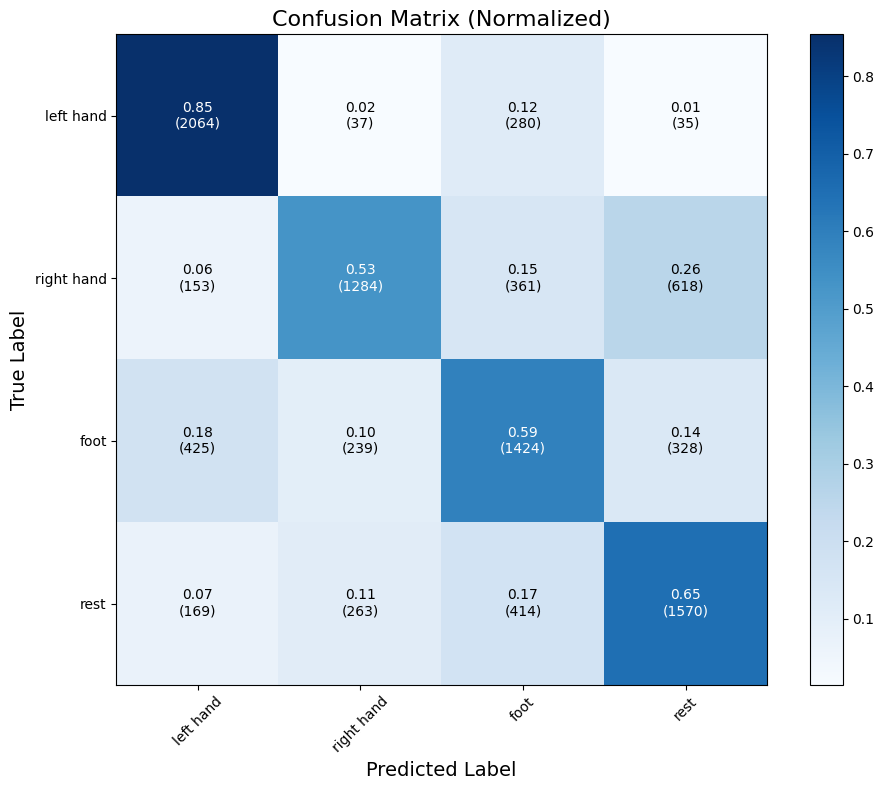


PER-CLASS ACCURACY
left hand      : 85.43% (2064/2416)
right hand     : 53.15% (1284/2416)
foot           : 58.94% (1424/2416)
rest           : 64.98% (1570/2416)
Overall        : 65.62% (6342/9664)

Generating embedding visualization...

Applying t-SNE...


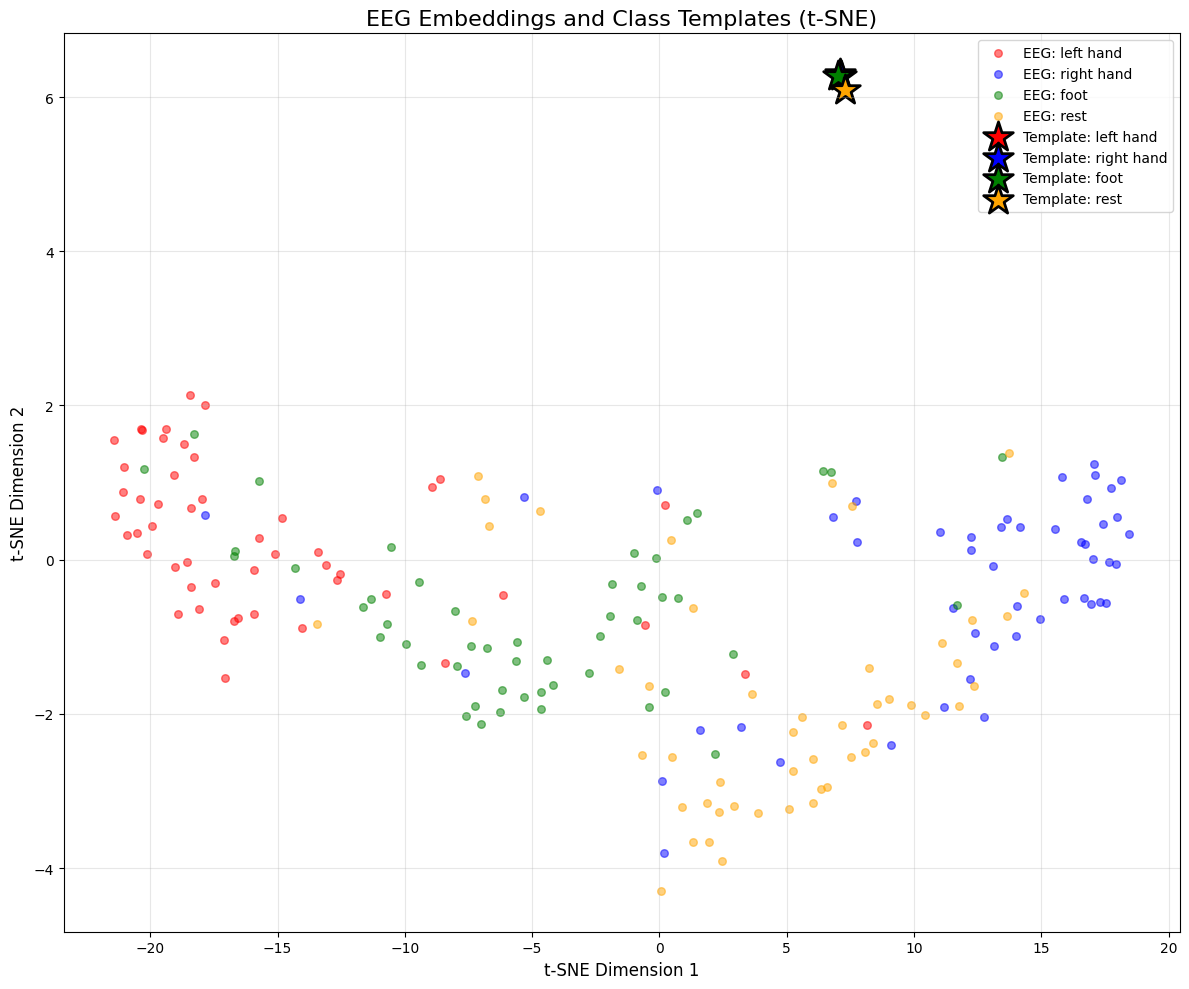


Evaluation complete!


In [19]:
# ============================================================================
# EVALUATION AND VISUALIZATION
# ============================================================================

def plot_confusion_matrix(confusion_matrix, class_names):
    """Plot confusion matrix"""
    import matplotlib.pyplot as plt
    
    # Normalize
    cm = confusion_matrix.numpy()
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix (Normalized)', fontsize=16)
    plt.colorbar()
    
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, f'{cm_normalized[i, j]:.2f}\n({int(cm[i, j])})',
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > 0.5 else "black")
    
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


def analyze_per_class_accuracy(confusion_matrix, class_names):
    """Calculate and display per-class accuracy"""
    cm = confusion_matrix.numpy()
    
    print("\n" + "="*80)
    print("PER-CLASS ACCURACY")
    print("="*80)
    
    for i, class_name in enumerate(class_names):
        class_total = cm[i].sum()
        class_correct = cm[i, i]
        class_acc = class_correct / class_total if class_total > 0 else 0
        print(f"{class_name:15s}: {class_acc*100:5.2f}% ({int(class_correct)}/{int(class_total)})")
    
    # Overall accuracy
    total_correct = np.trace(cm)
    total_samples = cm.sum()
    overall_acc = total_correct / total_samples
    print(f"{'Overall':15s}: {overall_acc*100:5.2f}% ({int(total_correct)}/{int(total_samples)})")
    print("="*80)


def visualize_embeddings(model, test_loader, num_samples=200):
    """Visualize EEG and class embeddings in 2D using t-SNE"""
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    
    model.eval()
    
    eeg_embeddings_list = []
    labels_list = []
    
    # Collect embeddings
    with torch.no_grad():
        for eeg_data, labels in test_loader:
            eeg_emb = model.model.eeg_encoder(eeg_data)
            eeg_embeddings_list.append(eeg_emb.cpu())
            labels_list.append(labels.cpu())
            
            if sum(len(l) for l in labels_list) >= num_samples:
                break
    
    # Concatenate
    eeg_embeddings = torch.cat(eeg_embeddings_list, dim=0)[:num_samples]
    labels = torch.cat(labels_list, dim=0)[:num_samples]
    
    # Get class embeddings
    class_embeddings = model.model.class_embeddings.cpu()
    
    # Combine for t-SNE
    all_embeddings = torch.cat([eeg_embeddings, class_embeddings], dim=0)
    
    # Apply t-SNE
    print("\nApplying t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(all_embeddings.numpy())
    
    # Split back
    eeg_2d = embeddings_2d[:num_samples]
    class_2d = embeddings_2d[num_samples:]
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    class_names = ["left hand", "right hand", "foot", "rest"]
    colors = ['red', 'blue', 'green', 'orange']
    
    # Plot EEG embeddings
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        mask = labels == i
        plt.scatter(eeg_2d[mask, 0], eeg_2d[mask, 1], 
                   c=color, label=f'EEG: {class_name}', alpha=0.5, s=30)
    
    # Plot class embeddings as stars
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.scatter(class_2d[i, 0], class_2d[i, 1],
                   c=color, marker='*', s=500, edgecolors='black', linewidths=2,
                   label=f'Template: {class_name}')
    
    plt.title('EEG Embeddings and Class Templates (t-SNE)', fontsize=16)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run evaluation
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)

class_names = ["left hand", "right hand", "foot", "rest"]

# Confusion matrix
print("\nGenerating confusion matrix...")
confusion = model.val_confusion.compute()
plot_confusion_matrix(confusion, class_names)

# Per-class accuracy
analyze_per_class_accuracy(confusion, class_names)

# Embedding visualization
print("\nGenerating embedding visualization...")
visualize_embeddings(model, val_loader, num_samples=200)

print("\nEvaluation complete!")

# Summary - 4-Class Contrastive Learning with Direct Embedding

## Key Innovation

This notebook implements a **modified CLIP approach** where:

1. **Fixed 4 class templates** instead of batch-dependent captions
2. Each EEG sample compared against **only 4 text embeddings**
3. Text embeddings **pre-computed once** (never recomputed)
4. **ATCNet outputs embeddings DIRECTLY** (no 4-class bottleneck)

## Architecture Comparison

| Aspect | Original (with bottleneck) | This Approach (Direct) |
|--------|---------------------------|------------------------|
| **ATCNet output** | 4 classes → 384 dim | 384 dim directly |
| **Feature flow** | Features → 4 classes → projection | Features → projection → embedding |
| **Bottleneck** | Yes (forced through 4D) | No bottleneck |
| **Feature capacity** | Limited by 4 classes | Full capacity |
| **Learning** | Two-stage (classify then project) | Single-stage (direct embedding) |

## Architecture Details

### Original Architecture (with bottleneck):
```
ATCNet → [4 classes] → Projection Head → 384-dim embedding
         ^bottleneck^
```

### New Architecture (direct embedding):
```
ATCNet → Feature Extraction → Projection Head → 384-dim embedding
         [256 dim × 3 windows → 768 dim → 512 dim → 768 dim → 384 dim]
         No bottleneck, direct path to embedding space
```

## Benefits of Direct Embedding

### ✅ **No Information Bottleneck**
- Features don't pass through 4-class bottleneck
- Preserves more information from EEG signal
- Better gradient flow during training

### ✅ **Better Feature Learning**
- Model learns features directly optimized for embedding space
- Not constrained by intermediate classification task
- More flexible representation learning

### ✅ **Unified Objective**
- Single optimization target (contrastive loss)
- No conflict between classification and embedding objectives
- Cleaner gradient signals

### ✅ **More Parameters**
- Richer projection pathway (256×3 → 768 → 512 → 768 → 384)
- Better capacity to learn complex mappings
- More expressive feature transformations

## Training Process

### Pre-computation (Once):
```python
# At model initialization:
class_captions = ["left hand movement", "right hand movement", 
                  "foot movement", "resting state"]
class_embeddings = text_encoder(class_captions)  # (4, 384)
# Frozen - never updated
```

### Each Training Step:
```python
# Input: batch of EEG (32, 1, 50, 1001) + labels (32,)
eeg_embeddings = eeg_encoder(eeg_data)           # (32, 384) - DIRECT output
logits = eeg_embeddings @ class_embeddings.T     # (32, 4)
loss = CrossEntropy(logits, labels)              # Compare to true class
```

## Expected Performance

| Metric | Expected Range |
|--------|---------------|
| **Random Baseline** | 25% |
| **After 10 epochs** | 45-65% (better than bottleneck) |
| **After 50 epochs** | 65-80% (better than bottleneck) |
| **Well-trained** | 75-90% (better than bottleneck) |
| **Excellent** | >90% |

## When to Use Direct Embedding vs Bottleneck

### Use Direct Embedding (This Approach) If:
- ✅ You want **maximum performance**
- ✅ You prioritize **feature quality** over interpretability
- ✅ You have **sufficient data** for end-to-end training
- ✅ You want **cleaner optimization**

### Use Bottleneck Approach If:
- ✅ You want **dual-purpose model** (classification + embedding)
- ✅ You need **intermediate class predictions**
- ✅ You want to **regularize** feature learning
- ✅ You have **limited data** (bottleneck acts as regularizer)

## Next Steps

1. **Train the model** and compare with bottleneck version
2. **Analyze embedding quality** using t-SNE visualization
3. **Compare convergence speed** with bottleneck approach
4. **Evaluate generalization** on test set
5. **Try different projection architectures** for optimal performance
